In [1]:
import numpy as np
import matplotlib.pyplot as plt
import os
os.chdir('/zhome/71/c/146676/main/')
import SimpleITK as sitk
import loader_XA_to_NA
import importlib
importlib.reload(loader_XA_to_NA)
import tifffile
import module_auxiliary as ma

The point of this notebook is to load in two registerred volumes and quantify how good the registration is. This is done by comparing slices of subvolumes.

In [2]:
reg = loader_XA_to_NA.load_registered_data(compression = 1, dataset_NA='tv', dataset_XA = 'tv')

Resampling the transformation
Resampling moving image


In [22]:
def registration_plotter(limits,thresholds):
    x0,x1,y0,y1,z0,z1 = limits
    fig, axes = plt.subplots(2, 3, figsize=(10, 7))  # 1 row, 3 columns
    fig.patch.set_facecolor('black')  # Set the background color to black
    clims = [(-0.02, 0.08), (-0.02, 0.08), (-1, 1)]
    val1 = reg.as_array(reg.fixed)[x0:x1,y0:y1,z0:z1].squeeze()
    im1 = axes[0,0].imshow(val1, cmap='viridis', vmin=clims[0][0], vmax=clims[0][1])
    axes[0,0].axis('off')

    val2 = reg.as_array(reg.moving)[x0:x1,y0:y1,z0:z1].squeeze()
    im2 = axes[0,1].imshow(val2, cmap='viridis', vmin=clims[1][0], vmax=clims[1][1])
    axes[0,1].axis('off')

    val2 = reg.as_array(reg.moving)[x0:x1,y0:y1,z0:z1].squeeze()
    im2 = axes[0,2].imshow(val2, cmap='gray', vmin=1, vmax=1)
    axes[0,2].axis('off')

    val1_th = (val1>thresholds[0])*1.0
    im2 = axes[1,0].imshow(val1_th, cmap='viridis', vmin=clims[2][0], vmax=clims[2][1])
    axes[1,0].axis('off')

    val2_th = (val2>thresholds[1])*1.0
    im2 = axes[1,1].imshow(val2_th, cmap='viridis', vmin=clims[2][0], vmax=clims[2][1])
    axes[1,1].axis('off')

    dif_val = val1_th - val2_th
    im2 = axes[1,2].imshow(dif_val, cmap='viridis', vmin=clims[2][0], vmax=clims[2][1])
    axes[1,2].axis('off')
    plt.subplots_adjust(wspace=0.1)
    plt.show()

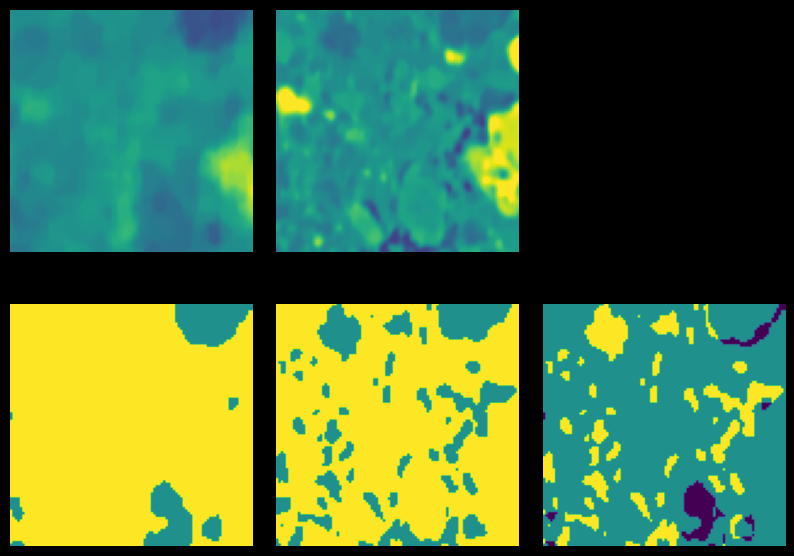

In [23]:
limits = (700, 701, 100, 200, 700, 800)
thresholds = (0.02, 0.026)
registration_plotter(limits, thresholds)

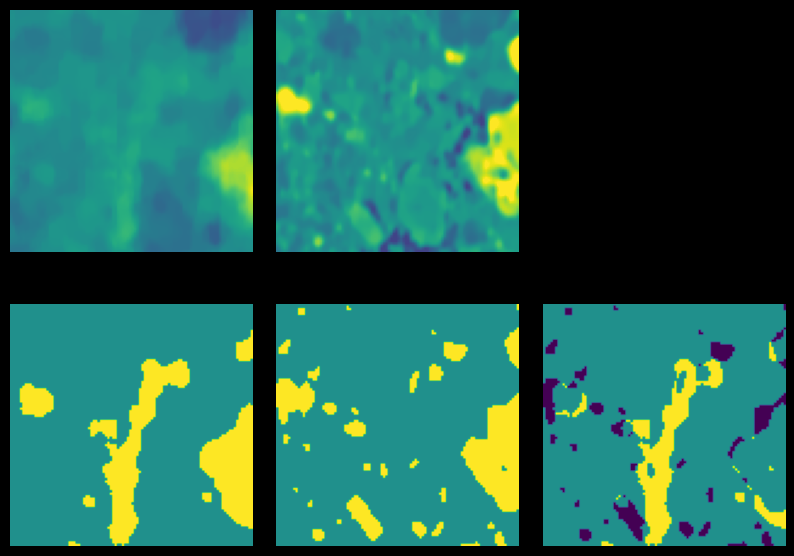

In [24]:
limits = (700, 701, 100, 200, 700, 800)
thresholds = (0.035, 0.04)
registration_plotter(limits, thresholds)

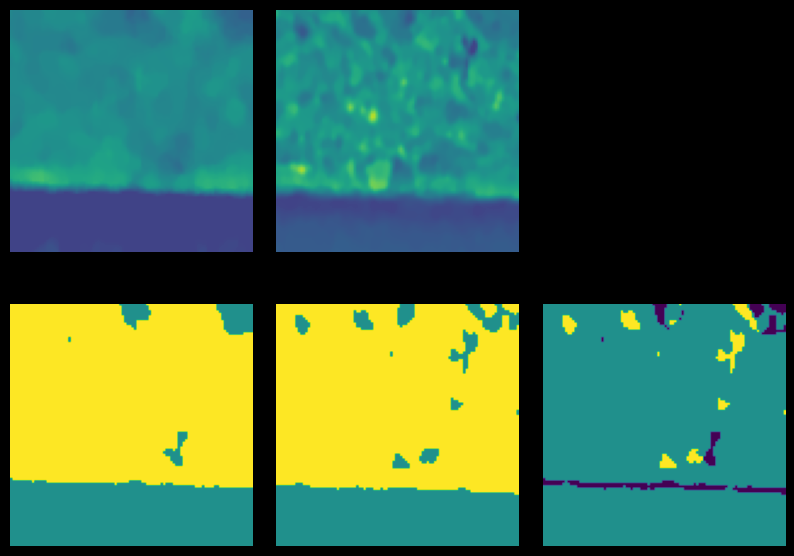

In [31]:
limits = (500, 501, 220, 320, 800, 900)
thresholds = (0.02, 0.02)
registration_plotter(limits, thresholds)

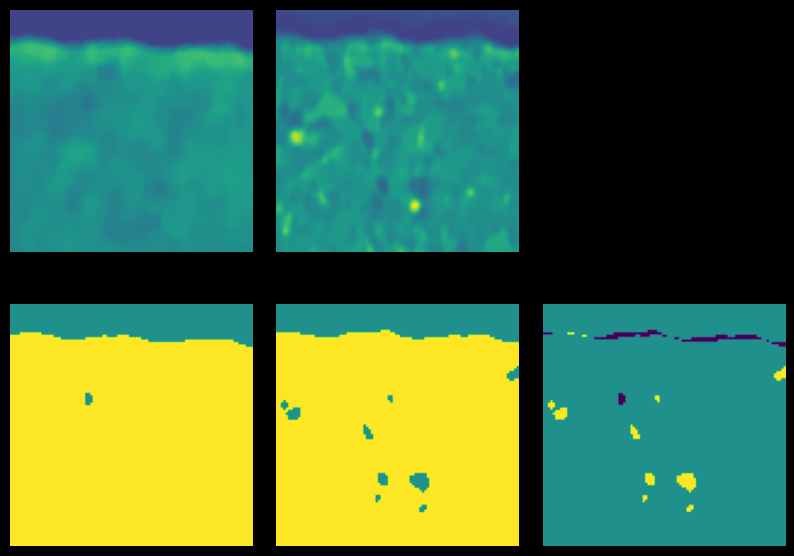

In [33]:
limits = (500, 501, 50, 150, 800, 900)
thresholds = (0.02, 0.02)
registration_plotter(limits, thresholds)

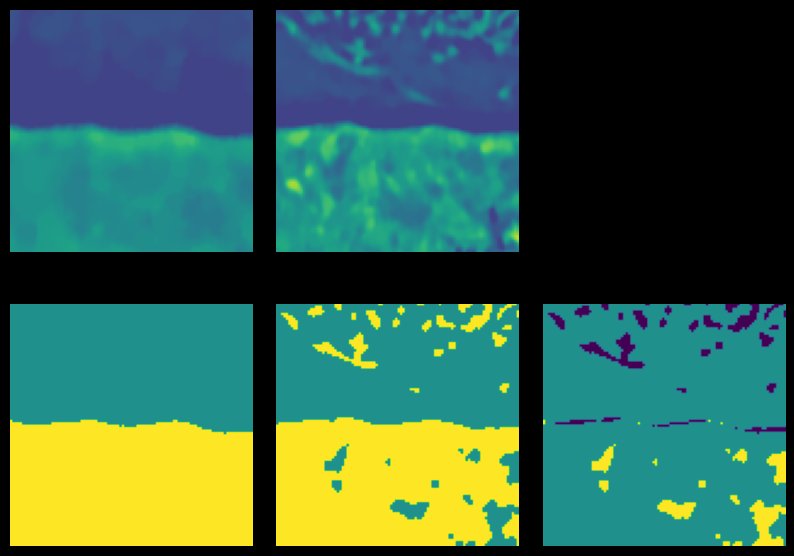

In [35]:
limits = (300, 301, 20, 120, 800, 900)
thresholds = (0.02, 0.02)
registration_plotter(limits, thresholds)

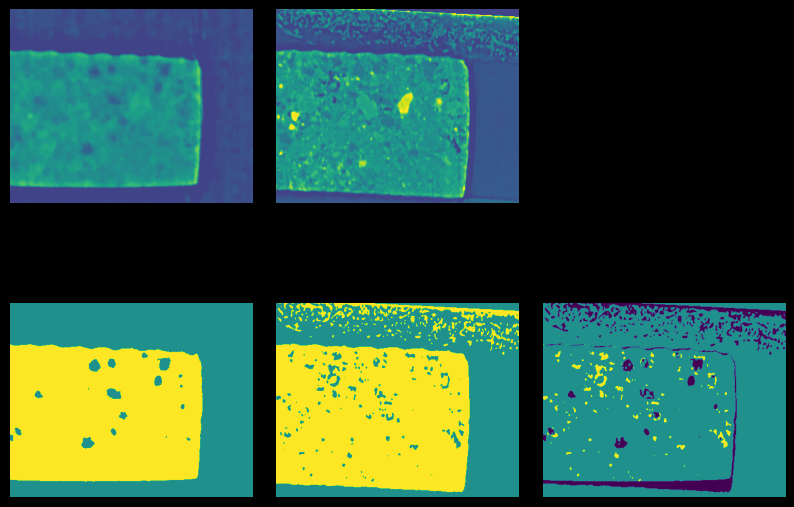

In [ ]:
limits = (300, 301, 0, 320, 800, 1200)
thresholds = (0.02, 0.02)
registration_plotter(limits, thresholds)

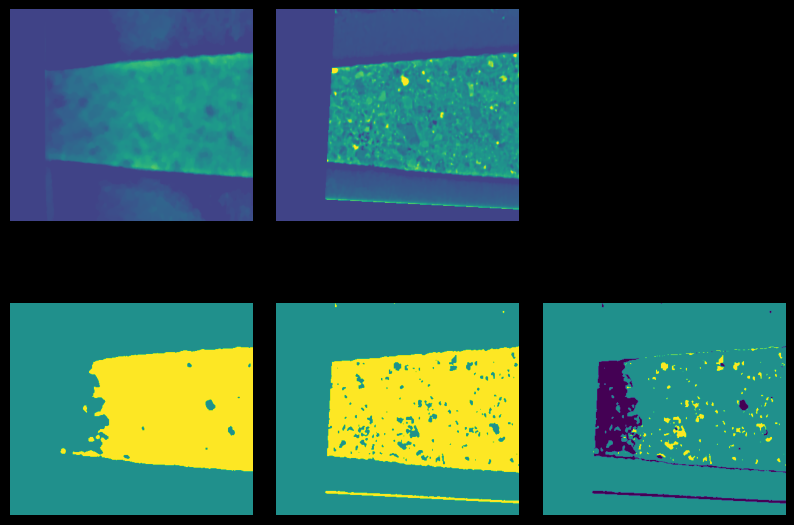

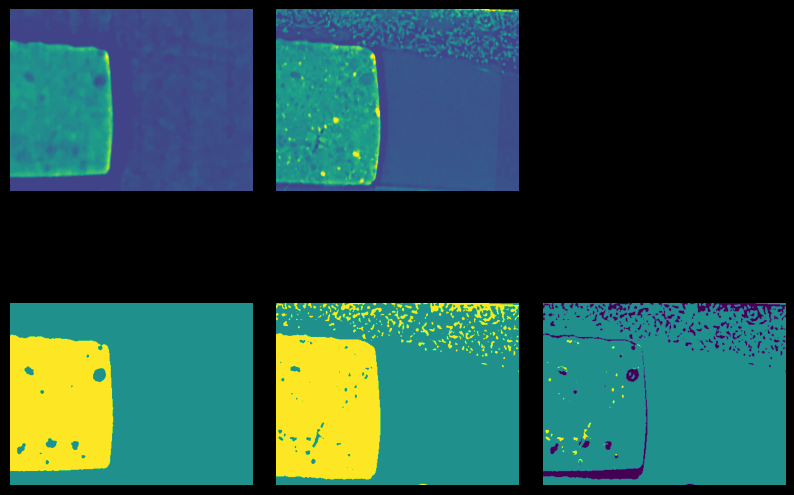

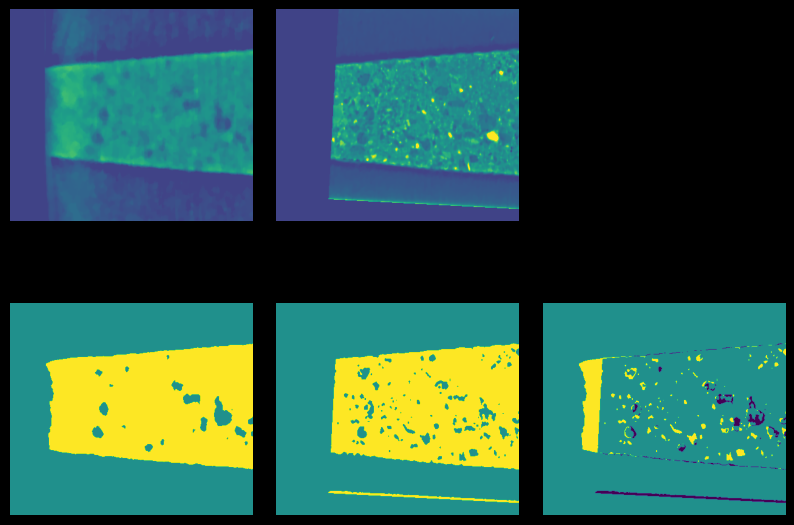

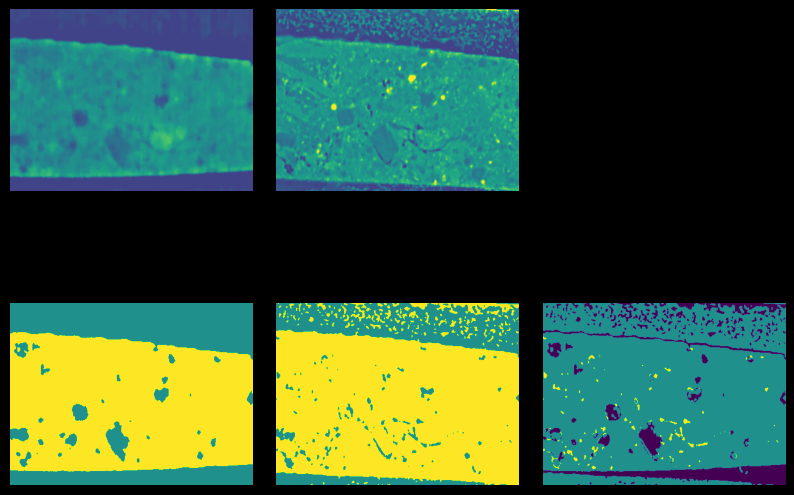

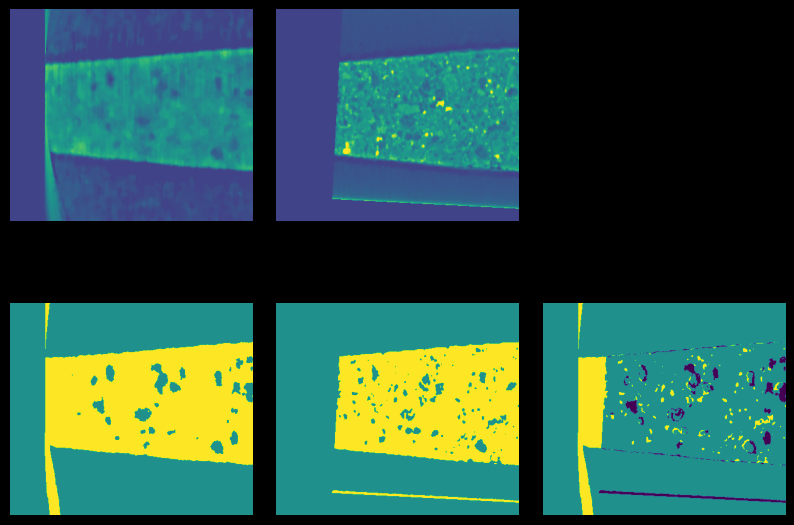

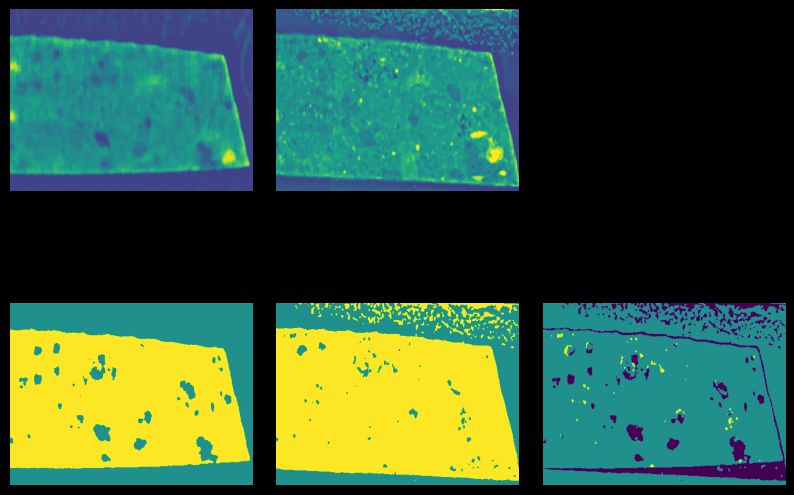

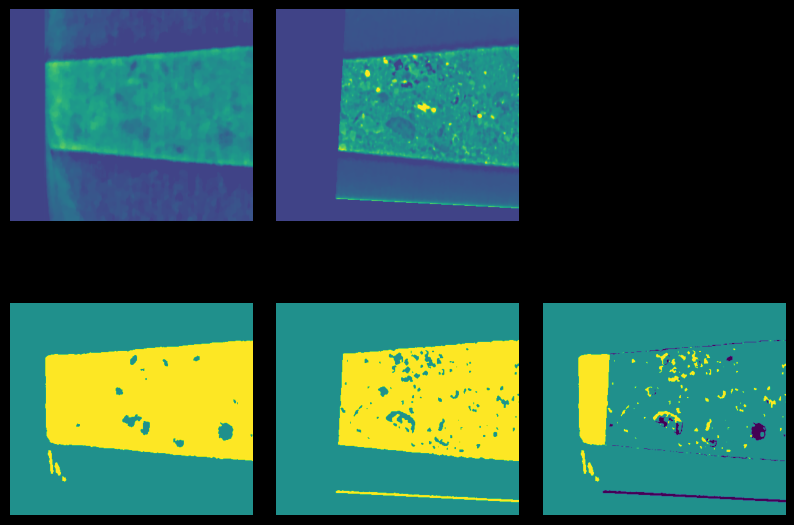

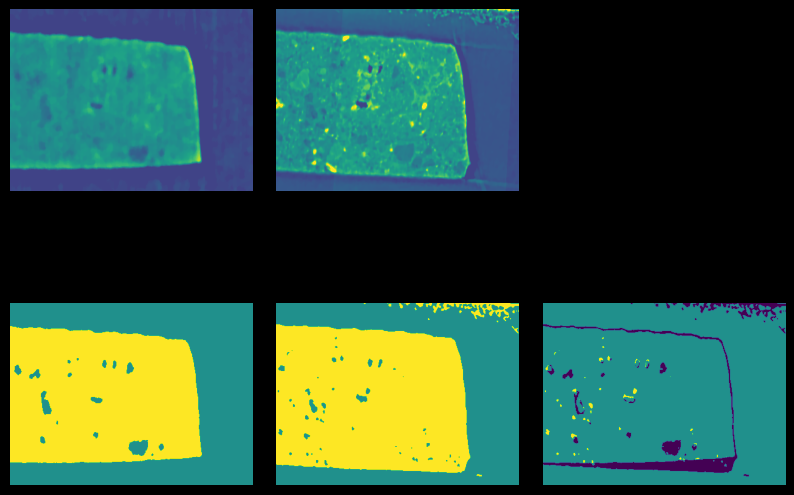

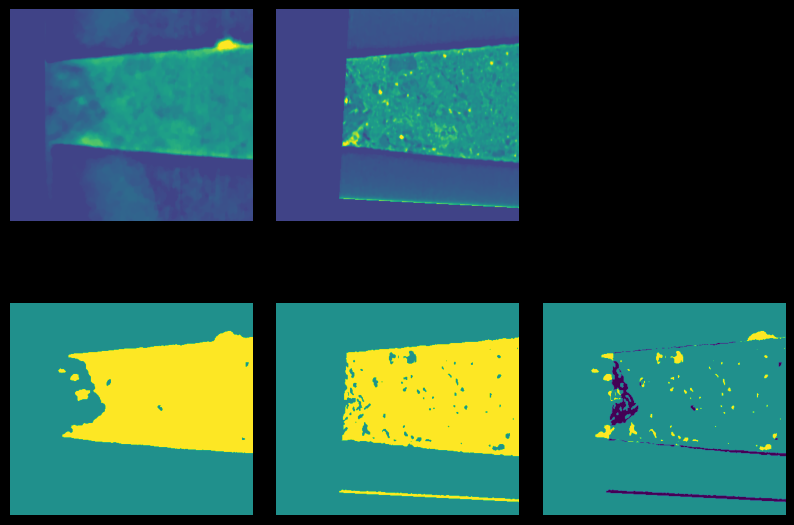

In [ ]:
for i in range(400,1700,250):
    limits = (i, i+1, 0, 350, 100, 500)
    thresholds = (0.02, 0.02)
    registration_plotter(limits, thresholds)



for i in range(400,1700,250):
    limits = (i, i+1, 20, 320, 1000, 1400)
    thresholds = (0.02, 0.02)
    registration_plotter(limits, thresholds)